# TP1 - Distributed Data Processing

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

## Initialize Spark Session

In [34]:
spark = SparkSession.builder \
	.appName("carlosleao_SpotifyDataAnalysis") \
	.config("spark.executor.instances", "2") \
	.config("spark.executor.cores", "2") \
	.config("spark.executor.memory", "2g") \
	.config("spark.driver.memory", "2g") \
	.getOrCreate()

spark.sparkContext.setLogLevel("ERROR")


## Create dataframes

In [35]:
playlist_df = spark.read.json("hdfs://localhost:9000/tp1/playlist.json")
track_df = spark.read.json("hdfs://localhost:9000/tp1/tracks.json")
joined_df = track_df.join(playlist_df, track_df.pid == playlist_df.pid, how="left").drop(playlist_df["pid"])

print(f"Playlists dataframe: {playlist_df.count()} ")
playlist_df.printSchema()
print()

print(f"Tracks dataframe: {track_df.count()} ")
track_df.printSchema()
print()

print(f"Joined dataframe: {joined_df.count()} ")
joined_df.printSchema()
print()

Playlists dataframe: 161000 
root
 |-- collaborative: string (nullable = true)
 |-- description: string (nullable = true)
 |-- duration_ms: long (nullable = true)
 |-- modified_at: long (nullable = true)
 |-- name: string (nullable = true)
 |-- num_albums: long (nullable = true)
 |-- num_artists: long (nullable = true)
 |-- num_edits: long (nullable = true)
 |-- num_followers: long (nullable = true)
 |-- num_tracks: long (nullable = true)
 |-- pid: long (nullable = true)




Tracks dataframe: 10760544 
root
 |-- album_name: string (nullable = true)
 |-- album_uri: string (nullable = true)
 |-- artist_name: string (nullable = true)
 |-- artist_uri: string (nullable = true)
 |-- duration_ms: long (nullable = true)
 |-- pid: long (nullable = true)
 |-- pos: long (nullable = true)
 |-- track_name: string (nullable = true)
 |-- track_uri: string (nullable = true)




Joined dataframe: 10760544 
root
 |-- album_name: string (nullable = true)
 |-- album_uri: string (nullable = true)
 |-- artist_name: string (nullable = true)
 |-- artist_uri: string (nullable = true)
 |-- duration_ms: long (nullable = true)
 |-- pid: long (nullable = true)
 |-- pos: long (nullable = true)
 |-- track_name: string (nullable = true)
 |-- track_uri: string (nullable = true)
 |-- collaborative: string (nullable = true)
 |-- description: string (nullable = true)
 |-- duration_ms: long (nullable = true)
 |-- modified_at: long (nullable = true)
 |-- name: string (nullable = true)
 |-- num_albums: long (nullable = true)
 |-- num_artists: long (nullable = true)
 |-- num_edits: long (nullable = true)
 |-- num_followers: long (nullable = true)
 |-- num_tracks: long (nullable = true)




## 1. Statistics about songs duration

On Spotify, there are albums with short tracks (like transitions between songs on an album or advertising) but there also exist songs that exceed 1 hour (for example, full concerts or mixes). These types of tracks can be considered an outlier.

In [36]:
def get_duration_stats(df):
  return df.select(
    F.min("duration_ms").alias("Minimum duration (ms)"),
    F.avg("duration_ms").alias("Average duration (ms)"),
    F.max("duration_ms").alias("Maximum duration (ms)"),
  )

### Generate a table containing the minimum, average and maximum duration, in milliseconds, of the songs in the dataset.

In [37]:
# 1. Create duration stats table
duration_stats = get_duration_stats(track_df)
duration_stats.show()

+---------------------+---------------------+---------------------+
|Minimum duration (ms)|Average duration (ms)|Maximum duration (ms)|
+---------------------+---------------------+---------------------+
|                    0|   234408.54976216817|             10435467|
+---------------------+---------------------+---------------------+



### Compute the first and third quartiles (denoted Q1 and Q3), as well as the interquartile range (IRQ) (Q3 - Q1).

In [38]:
# 2. Compute first and third quartiles as well the interquartile range
quantiles = track_df.approxQuantile("duration_ms", [0.25, 0.75], 0.00001)
Q1 = quantiles[0]
Q3 = quantiles [1]
IQR = Q3 - Q1
print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR (Interquartile Range): {IQR}")

Q1 (25th percentile): 198333.0
Q3 (75th percentile): 258834.0
IQR (Interquartile Range): 60501.0


### Compute the set of songs with durations that are not outliers, as defined by the IQRR methodology.

In [39]:
# 3. Compute the set of songs with durations that are not outliers
# Q1 - 1.5 * IQR < X < Q3 + 1.5 * IQR
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
not_outliers_tracks = track_df.where((track_df.duration_ms > lower_limit) & (track_df.duration_ms < upper_limit))
num_outliers = track_df.count() - not_outliers_tracks.count()
not_outliers_duration_stats = get_duration_stats(not_outliers_tracks)
print(f"Number of outliers: {num_outliers}")
not_outliers_duration_stats.show()

Number of outliers: 559989


+---------------------+---------------------+---------------------+
|Minimum duration (ms)|Average duration (ms)|Maximum duration (ms)|
+---------------------+---------------------+---------------------+
|               107582|   226899.35353939075|               349583|
+---------------------+---------------------+---------------------+



## 2. Finding the most popular artists over time

Finding popular artists can be interesting to analyze user tendencies and to inform organizations preparing advertising campaigns. In this task, find the five most popular artists ranked by the number of playlists they appear in. Create a chart that shows the number of playlists containing each of these five artists over the years. Consider that an artist is present in a playlist after each playlist's last modification date.

### Top 5 artists

In [40]:
top_artists = (
    track_df
    .groupBy("artist_name") 
    .agg(F.countDistinct("pid").alias("playlist_count")) 
    .orderBy(F.desc("playlist_count"))  
    .limit(5)
)
top_artists \
    .withColumnRenamed("artist_name", "Artist name") \
    .withColumnRenamed("playlist_count", "Number of playlists") \
    .show()

+--------------+-------------------+
|   Artist name|Number of playlists|
+--------------+-------------------+
|         Drake|              32259|
|       Rihanna|              23963|
|    Kanye West|              22464|
|    The Weeknd|              20046|
|Kendrick Lamar|              19159|
+--------------+-------------------+



### Number of Playlists Containing Each Artist Over the Years

In [41]:
tracks_listened_per_year = joined_df.withColumn("modified_year", F.year(F.from_unixtime(joined_df.modified_at))).select("artist_name", "pid", "modified_year")

top_artist_names = [row.artist_name for row in top_artists.collect()]

top_artists_count_by_year = (
  tracks_listened_per_year \
    .filter(F.col("artist_name").isin(top_artist_names)) \
    .groupBy("artist_name", "modified_year") \
    .agg(F.countDistinct("pid").alias("playlist_count")) \
    .sort("artist_name", "modified_year", ascending=[True, True]) 
)
top_artists_count_by_year \
  .withColumnRenamed("artist_name", "Artist name") \
  .withColumnRenamed("playlist_count", "Number of playlists") \
  .withColumnRenamed("modified_year", "Year") \
  .show()


+--------------+----+-------------------+
|   Artist name|Year|Number of playlists|
+--------------+----+-------------------+
|         Drake|2012|                 24|
|         Drake|2013|                523|
|         Drake|2014|                880|
|         Drake|2015|               2517|
|         Drake|2016|               7844|
|         Drake|2017|              20471|
|    Kanye West|2011|                  4|
|    Kanye West|2012|                 25|
|    Kanye West|2013|                463|
|    Kanye West|2014|                820|
|    Kanye West|2015|               1880|
|    Kanye West|2016|               5121|
|    Kanye West|2017|              14151|
|Kendrick Lamar|2012|                  5|
|Kendrick Lamar|2013|                279|
|Kendrick Lamar|2014|                506|
|Kendrick Lamar|2015|               1304|
|Kendrick Lamar|2016|               2695|
|Kendrick Lamar|2017|              14370|
|       Rihanna|2011|                  1|
+--------------+----+-------------

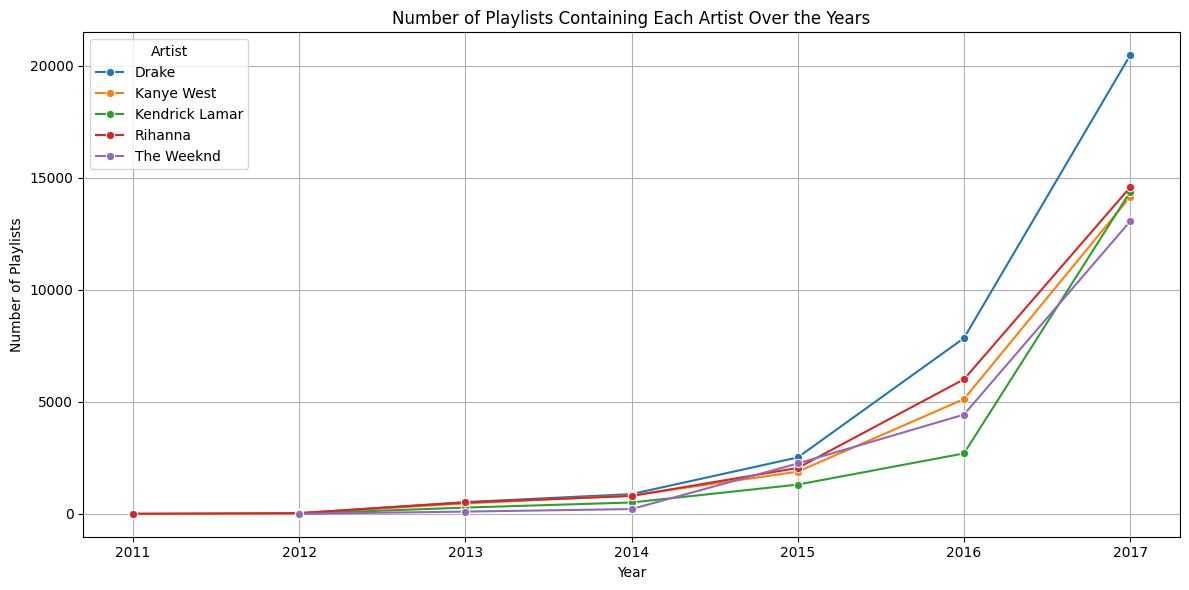

In [42]:
top_artists_pandas = top_artists_count_by_year.toPandas()

plt.figure(figsize=(12, 6))
sns.lineplot(data=top_artists_pandas, x="modified_year", y="playlist_count", hue="artist_name", marker="o")

plt.title('Number of Playlists Containing Each Artist Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Playlists')
plt.legend(title="Artist", loc="upper left")
plt.grid(True)
plt.tight_layout()

plt.show()

## Playlists's behavior

Playlists collect different songs by user preference, musical genre, or a variety of other relationships. In this sense, your task is analyzing how playlists are being created. What is more common: Playlists where there are many songs by the same artist or playlists with more diverse songs? To answer this question, compute the prevalence of the most frequent artist in each playlist, defined as the fraction of songs by the most frequent artist. Then create a Cumulative Distribution Function (CDF) plot containing the distribution of artist prevalence across all playlists.

In [43]:
# 1. Group by pid and artist_name, count occurrences
artists_occurrence_per_playlist = (
  joined_df \
    .groupBy("pid", "artist_name", "num_tracks") \
    .count()
)

# 2. Define a window specification to rank artists by count within each pid
window_spec = Window.partitionBy("pid").orderBy(F.desc("count"))

# 3. Add a rank column based on the count
artists_occurrence_per_playlist = artists_occurrence_per_playlist.withColumn(
  "rank", F.row_number().over(window_spec)
)

# 4. Filter to keep only the most frequent artist (rank = 1)
most_frequent_artists = artists_occurrence_per_playlist.filter(artists_occurrence_per_playlist.rank == 1)

# 5. Calculate the prevalence of the most frequent artist in each playlist and sort it
most_frequent_artists = most_frequent_artists.withColumn(
  "prevalence", F.col("count") / F.col("num_tracks")
).sort("prevalence", ascending=[True])

# 6. Calculate the cumulative sum
window_spec = Window.orderBy("prevalence")
most_frequent_artists = most_frequent_artists.withColumn(
  "cumulative_prevalence",
  F.sum(F.col("prevalence")).over(window_spec)
)

# 7. Normalize cumulative_prevalence to create a proper CDF
total_prevalence = most_frequent_artists.select(
  F.max(F.col("cumulative_prevalence")).alias("total_cumulative_prevalence")
).collect()[0]["total_cumulative_prevalence"]

most_frequent_artists = most_frequent_artists.withColumn(
  "normalized_cumulative_prevalence",
  F.col("cumulative_prevalence") / total_prevalence
)

most_frequent_artists \
  .withColumnRenamed("pid", "Playlist ID") \
  .withColumnRenamed("artist_name", "Artist Name") \
  .withColumnRenamed("num_tracks", "Total Tracks") \
  .withColumnRenamed("count", "Artist Tracks") \
  .withColumnRenamed("rank", "Artist Rank") \
  .withColumnRenamed("prevalence", "Prevalence") \
  .withColumnRenamed("cumulative_prevalence", "Cumulative Prevalence") \
  .withColumnRenamed("normalized_cumulative_prevalence", "Normalized Prevalence") \
  .show()

+-----------+--------------------+------------+-------------+-----------+--------------------+---------------------+---------------------+
|Playlist ID|         Artist Name|Total Tracks|Artist Tracks|Artist Rank|          Prevalence|Cumulative Prevalence|Normalized Prevalence|
+-----------+--------------------+------------+-------------+-----------+--------------------+---------------------+---------------------+
|     110751|              Mitski|         188|            1|          1|0.005319148936170213| 0.005319148936170213| 2.084974120872444...|
|     139006|        Nicolas Jaar|         166|            1|          1|0.006024096385542169|  0.01134324532171238| 4.446270113185816E-7|
|     117671|     City and Colour|         162|            1|          1|0.006172839506172839|  0.01751608482788522| 6.865869710247665E-7|
|      49707|   The Weather Girls|         161|            1|          1|0.006211180124223602|  0.02372726495210882| 9.300497876235363E-7|
|     105034|         Willy

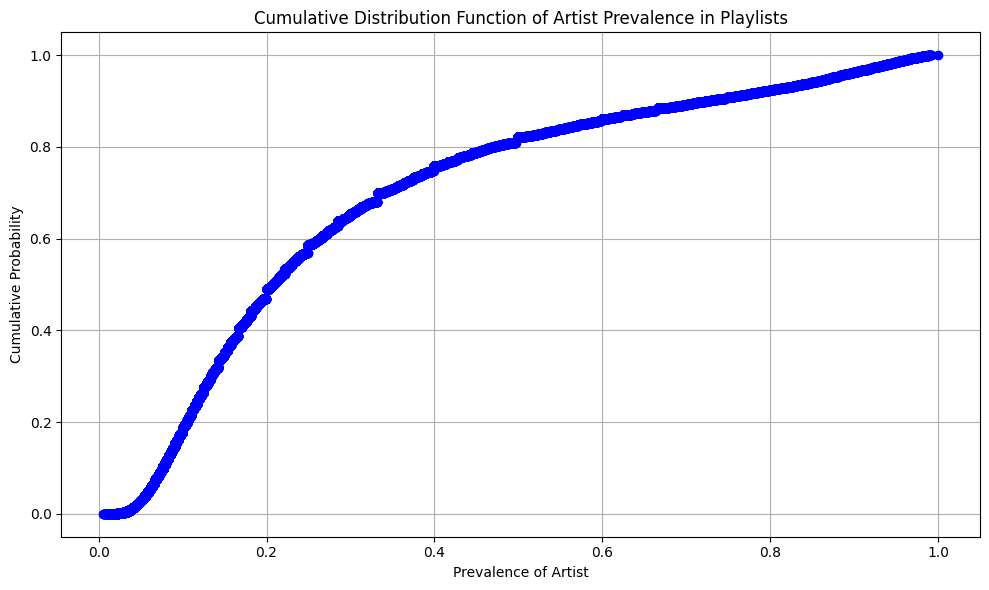

In [44]:
# Convert the Spark DataFrame to Pandas DataFrame
most_frequent_artists_pd = most_frequent_artists.toPandas()

# Plot the CDF
plt.figure(figsize=(10, 6))
plt.plot(most_frequent_artists_pd['prevalence'], most_frequent_artists_pd['normalized_cumulative_prevalence'], marker="o", linestyle='-', color='b')
plt.title('Cumulative Distribution Function of Artist Prevalence in Playlists')
plt.xlabel('Prevalence of Artist')
plt.ylabel('Cumulative Probability')
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()